<a href="https://colab.research.google.com/github/akash-321/hate-speech-detection-RAG/blob/main/notebooks/rag_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#RAG Experiment: Retrieval-Augmented Hate Speech Classification

### Installing libraries and set the random seed

In [1]:
!pip install -q sentence-transformers faiss-cpu wikipedia-api emoji
!pip install -q transformers datasets accelerate evaluate
!pip uninstall -y torchvision torchaudio -q



import pandas as pd
import numpy as np
import torch
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

FIG_DIR = "/content/drive/MyDrive/dissertation/figures"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.2/129.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.1/721.1 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00


## Loading the same data used for the baseline model

In [2]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/dissertation"
os.makedirs(FIG_DIR, exist_ok=True)

train_c = pd.read_csv(f"{SAVE_DIR}/train_c.csv")
val_c = pd.read_csv(f"{SAVE_DIR}/val_c.csv")
test_c  = pd.read_csv(f"{SAVE_DIR}/test_with_my_predictions.csv")

print("Train:", len(train_c), "| Val:", len(val_c), "| Test:", len(test_c))
print("Test columns:", list(test_c.columns))

def save_fig(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=200, bbox_inches="tight")
    plt.show()

Mounted at /content/drive
Train: 3795 | Val: 549 | Test: 1084
Test columns: ['comment_id', 'text', 'mean_score', 'target_group', 'label_3', 'label_bin', 'pred_3', 'my_pred_bin']


### Building the corpus from wikipedia

In [3]:
import wikipediaapi

wiki = wikipediaapi.Wikipedia(
    user_agent="MSc-dissertation-hate-speech (academic use)",
    language="en"
)

pages_per_religion = {
    "islam": ["Islam", "Muslims", "Quran", "Muhammad", "Ramadan", "Hijab",
              "Mosque", "Eid al-Fitr", "Halal", "Sharia", "Allah",
              "Niqab", "Burqa", "Imam", "Hajj", "Islamophobia", "Jihad"],
    "christianity": ["Christianity", "Jesus", "Bible", "Church (building)",
                     "Christmas", "Easter", "Baptism", "Priest", "Christian cross",
                     "Catholic Church", "Protestantism", "Pope", "Nun", "Evangelicalism"],
    "judaism": ["Judaism", "Jews", "Torah", "Synagogue", "Kippah", "Kosher",
                "Shabbat", "The Holocaust", "Antisemitism", "Rabbi",
                "Zionism", "Hanukkah", "Israel", "Orthodox Judaism"],
    "atheism": ["Atheism", "Agnosticism", "Secularism", "Irreligion",
                "Humanism", "Freethought"],
    "buddhism": ["Buddhism", "Gautama Buddha", "Bhikkhu", "Meditation",
                 "Buddhist temple", "Dharma", "Nirvana",
                 "Dalai Lama", "Tibetan Buddhism", "Karma"],
}

def split_into_chunks(text, sentences_per_chunk=2):
    sentences = re.split(r"(?<=[.!?])\s+", text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 30]
    return [" ".join(sentences[i:i+sentences_per_chunk])
            for i in range(0, len(sentences), sentences_per_chunk)]

corpus, corpus_meta = [], []
for religion, titles in pages_per_religion.items():
    for title in titles:
        page = wiki.page(title)
        if not page.exists():
            print("MISSING PAGE:", title)
            continue
        for chunk in split_into_chunks(page.summary):
            corpus.append(chunk)
            corpus_meta.append({"religion": religion, "page": title, "text": chunk})

print("Corpus size:", len(corpus), "chunks")
pd.DataFrame(corpus_meta).to_csv(f"{SAVE_DIR}/wiki_corpus.csv", index=False)

Corpus size: 460 chunks


###  Load the raw annotation-level splits

In [4]:
train_df = pd.read_csv(f"{SAVE_DIR}/train.csv")
val_df = pd.read_csv(f"{SAVE_DIR}/val.csv")

test_c = pd.read_csv(f"{SAVE_DIR}/test_with_my_predictions.csv")
print("test_c columns:", test_c.columns.tolist())

test_c columns: ['comment_id', 'text', 'mean_score', 'target_group', 'label_3', 'label_bin', 'pred_3', 'my_pred_bin']


### Preprocessing and comment-level aggregation

In [5]:
import re, emoji

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", "[URL]", text)
    text = re.sub(r"@\w+", "[USER]", text)
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = re.sub(r"\s+", " ", text).strip()
    return text

def build_comment_level(df):
    c = (df.groupby("comment_id").agg(text=("text", "first"),
                mean_score=("hate_speech_score", "mean")).reset_index())
    c["text"] = c["text"].map(preprocess)
    c["label_3"] = np.select(
        [c["mean_score"] < -1, c["mean_score"] <= 0.5],
        [0, 1],
        default=2
    ).astype(int)
    return c

train_c = build_comment_level(train_df)
val_c = build_comment_level(val_df)

print("Train:", len(train_c), "| Val:", len(val_c))
print("train_c columns:", train_c.columns.tolist())

Train: 3795 | Val: 549
train_c columns: ['comment_id', 'text', 'mean_score', 'label_3']


### Save comment-level files to Drive

In [6]:
train_c[["comment_id", "text", "mean_score", "label_3"]].to_csv(f"{SAVE_DIR}/train_c.csv", index=False)
val_c[["comment_id", "text", "mean_score", "label_3"]].to_csv(f"{SAVE_DIR}/val_c.csv", index=False)

In [7]:
for df in (train_c, val_c):
    df["label_3"] = np.select(
        [df["mean_score"] < -1, df["mean_score"] <= 0.5],
        [0, 1],
        default=2
    ).astype(int)

### Reloading the frozen corpus

In [8]:

corpus_df = pd.read_csv(f"{SAVE_DIR}/wiki_corpus.csv")
corpus = corpus_df["text"].tolist()
print("Loaded corpus:", len(corpus), "chunks")

Loaded corpus: 460 chunks


## Encoding the corpus and build the FAISS index

In [10]:
from sentence_transformers import SentenceTransformer
import faiss

encoder = SentenceTransformer("all-MiniLM-L6-v2")

corpus_vectors = encoder.encode(corpus, convert_to_numpy=True,
                                show_progress_bar=True).astype("float32")

index = faiss.IndexFlatL2(corpus_vectors.shape[1])
index.add(corpus_vectors)
print("FAISS index built with", index.ntotal, "chunks")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

FAISS index built with 460 chunks


### Calibrating the retrieval distance threshold


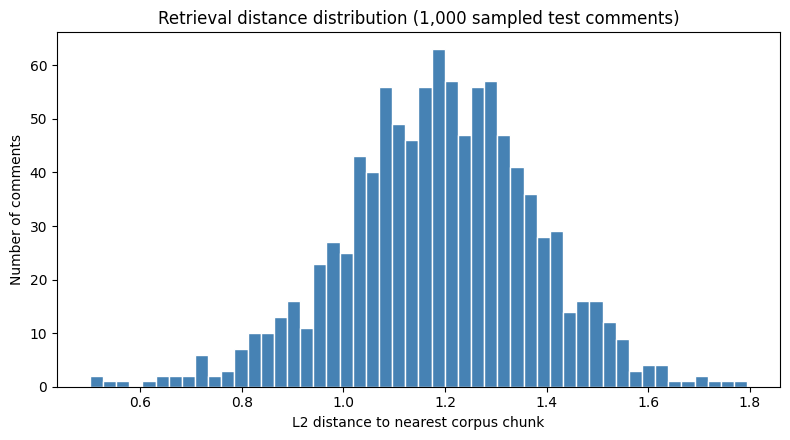

Percentiles:
 10th: 0.951
 25th: 1.073
 40th: 1.148
 50th: 1.192
 75th: 1.307

Candidate cutoff (30th pct): 1.094

SKIP    (d=1.09): [USER] muslims want to rape and destroy america. but okay.
SKIP    (d=1.09): gee cair and all the muslims didn't come forward to decry this man with their vision of pe
ATTACH  (d=1.09): god damnit ahmed, stealing my allah sword again?
ATTACH  (d=1.09): the lds "church" is a racist cult that protects rapists and child molesters.
SKIP    (d=1.10): your plan is becoming clear. antisemitism is rife throughout labour. you openly support ha
ATTACH  (d=1.09): honk honkler are you hearing what you wrote? you're arguing that a religion would have an 
SKIP    (d=1.10): i was a secular and all in my family is secular, even though i've converted. not all here 
ATTACH  (d=1.09): same, being devoted to atheism in the 21st century is stupid. by all means, be devoted to 
ATTACH  (d=1.09): [USER] long live israel! greetings from the netherlands.
ATTACH  (d=1.09): hijab ne

In [11]:
sample = test_c["text"].astype(str).sample(1000, random_state=SEED).tolist()
qv = encoder.encode(sample, convert_to_numpy=True).astype("float32")
d, _ = index.search(qv, 1)

plt.figure(figsize=(8, 4.5))
plt.hist(d[:, 0], bins=50, color="steelblue", edgecolor="white")
plt.xlabel("L2 distance to nearest corpus chunk")
plt.ylabel("Number of comments")
plt.title("Retrieval distance distribution (1,000 sampled test comments)")
save_fig("retrieval_distance_distribution")

print("Percentiles:")
for p in [10, 25, 40, 50, 75]:
    print(f" {p}th: {np.percentile(d[:, 0], p):.3f}")

CANDIDATE = np.percentile(d[:, 0], 30)
print(f"\nCandidate cutoff (30th pct): {CANDIDATE:.3f}\n")
order = np.argsort(np.abs(d[:, 0] - CANDIDATE))[:10]
for i in order:
    side = "ATTACH " if d[i, 0] <= CANDIDATE else "SKIP   "
    print(f"{side} (d={d[i,0]:.2f}): {sample[i][:90]}")

### Batched retrieval function and sanity check

In [12]:
MAX_DISTANCE = 1.1
def retrieve_context_batch(texts, k=1, batch_size=256, max_distance=MAX_DISTANCE):
    """Retrieve nearest chunk per comment; return '' when no confident match."""
    texts = [str(t) for t in texts]
    query_vectors = encoder.encode(
        texts, batch_size=batch_size,
        show_progress_bar=True, convert_to_numpy=True
    ).astype("float32")
    distances, positions = index.search(query_vectors, k)

    contexts = []
    for dist_row, pos_row in zip(distances, positions):
        if dist_row[0] <= max_distance:
            contexts.append(corpus[pos_row[0]])
        else:
            contexts.append("")
    return contexts


examples = [
    "she wears that thing on her head everywhere she goes",
    "those monks in robes are everywhere in this city",
    "the traffic on the motorway this morning was terrible",
    "I had pasta for dinner and it was great",
]
for text, ctx in zip(examples, retrieve_context_batch(examples)):
    print(f"COMMENT:   {text}\nRETRIEVED: {ctx[:150] if ctx else '(none — below threshold)'}\n")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

COMMENT:   she wears that thing on her head everywhere she goes
RETRIEVED: (none — below threshold)

COMMENT:   those monks in robes are everywhere in this city
RETRIEVED: A Buddhist temple or Buddhist monastery is the place of worship for adherents of Buddhism. They include the structures called vihara, chaitya, stupa, 

COMMENT:   the traffic on the motorway this morning was terrible
RETRIEVED: (none — below threshold)

COMMENT:   I had pasta for dinner and it was great
RETRIEVED: (none — below threshold)



### Set creation

In [13]:
def augment(df):
    assert "label_3" in df.columns, f"label_3 missing! Columns: {df.columns.tolist()}"
    df = df.copy()
    contexts = retrieve_context_batch(df["text"].tolist())
    df["text_rag"] = [
        str(t) + " [SEP] background: " + c if c else str(t)
        for t, c in zip(df["text"], contexts)
    ]
    df["has_context"] = [bool(c) for c in contexts]
    return df

train_rag = augment(train_c)
val_rag = augment(val_c)
test_rag = augment(test_c)

print("Share of comments receiving context:")
print(f"  train: {train_rag['has_context'].mean():.1%}")
print(f"  val: {val_rag['has_context'].mean():.1%}")
print(f"  test: {test_rag['has_context'].mean():.1%}")


train_rag.to_csv(f"{SAVE_DIR}/train_rag.csv", index=False)
val_rag.to_csv(f"{SAVE_DIR}/val_rag.csv", index=False)
test_rag.to_csv(f"{SAVE_DIR}/test_rag.csv", index=False)

print("\nExample WITH context:")
print(test_rag[test_rag["has_context"]]["text_rag"].iloc[0][:300])

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Share of comments receiving context:
  train: 29.8%
  val: 29.7%
  test: 31.1%

Example WITH context:
well, he's got my support because this is anti-jew. [SEP] background: Antisemitism, or Jew-hatred, is hostility to, prejudice towards, or discrimination against Jews. A person who harbours it is called an antisemite.


### Checking input lengths

In [14]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

lengths = [len(tokenizer(t)["input_ids"]) for t in test_rag["text_rag"].sample(500, random_state=SEED)]
print("Median length:", int(np.median(lengths)))
print("Max length: ", max(lengths))
print("Over 256: ", sum(l > 256 for l in lengths), "of 500 sampled")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Median length: 53
Max length:  276
Over 256:  1 of 500 sampled


### Retrain BERT on the augmented text

In [15]:
from datasets import Dataset
from transformers import (AutoModelForSequenceClassification, TrainingArguments,
                          Trainer, EarlyStoppingCallback, DataCollatorWithPadding)
import torch.nn as nn
import evaluate

MAX_LEN = 256

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

collator = DataCollatorWithPadding(tokenizer)

def make_ds(df):
    ds = Dataset.from_pandas(df[["text_rag", "label_3"]].rename(columns={"text_rag": "text", "label_3": "labels"}))
    ds = ds.map(tokenize, batched=True)
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    return ds

train_ds_rag = make_ds(train_rag)
val_ds_rag = make_ds(val_rag)
test_ds_rag = make_ds(test_rag)

Map:   0%|          | 0/3795 [00:00<?, ? examples/s]

Map:   0%|          | 0/549 [00:00<?, ? examples/s]

Map:   0%|          | 0/1084 [00:00<?, ? examples/s]

### Class weights and weighted-loss Trainer

In [16]:
counts = train_rag["label_3"].value_counts().sort_index().values
weights = counts.sum() / (len(counts) * counts)
class_weights = torch.tensor(weights, dtype=torch.float)

class WeightedLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(outputs.logits.device))
        loss = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

acc = evaluate.load("accuracy")
f1  = evaluate.load("f1")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": acc.compute(predictions=preds, references=labels)["accuracy"],"f1_macro": f1.compute(predictions=preds, references=labels, average="macro")["f1"]}

### Training run

In [17]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)

training_args = TrainingArguments(
    output_dir=f"{SAVE_DIR}/bert_rag_best",
    learning_rate=1e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    report_to="none",
)

trainer = WeightedLossTrainer(
    model=model, args=training_args,
    train_dataset=train_ds_rag, eval_dataset=val_ds_rag,
    data_collator=collator, compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()
trainer.save_model(f"{SAVE_DIR}/bert_rag_final")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.048992,0.929890,0.582878,0.537046
2,0.848682,0.797237,0.652095,0.642579
3,0.735958,0.784405,0.637523,0.622119
4,0.639847,0.788833,0.642987,0.626314


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Prediction on the test set and compare overall performance

In [18]:
from sklearn.metrics import accuracy_score, f1_score

pred_out = trainer.predict(test_ds_rag)
test_rag["rag_pred_3"] = np.argmax(pred_out.predictions, axis=1)
test_rag["rag_pred_bin"] = (test_rag["rag_pred_3"] == 2).astype(int)

print("Baseline accuracy:", round(accuracy_score(test_rag["label_bin"], test_rag["my_pred_bin"]), 4))
print("RAG accuracy: ", round(accuracy_score(test_rag["label_bin"], test_rag["rag_pred_bin"]), 4))
print("Baseline F1: ", round(f1_score(test_rag["label_bin"], test_rag["my_pred_bin"]), 4))
print("RAG F1: ", round(f1_score(test_rag["label_bin"], test_rag["rag_pred_bin"]), 4))

test_rag.to_csv(f"{SAVE_DIR}/test_rag_predictions.csv", index=False)

Baseline accuracy: 0.833
RAG accuracy:  0.8137
Baseline F1:  0.6472
RAG F1:  0.5976


### Per-religion comparison

In [19]:
rows = []
for religion, sub in test_rag.groupby("target_group"):
    rows.append({
        "religion": religion.replace("target_religion_", ""),
        "n": len(sub),
        "baseline_acc": round(accuracy_score(sub["label_bin"], sub["my_pred_bin"]), 4),
        "rag_acc": round(accuracy_score(sub["label_bin"], sub["rag_pred_bin"]), 4),
    })
comparison = pd.DataFrame(rows)
comparison["change"] = (comparison["rag_acc"] - comparison["baseline_acc"]).round(4)
comparison.sort_values("change")

,religion,n,baseline_acc,rag_acc,change
0,atheist,36,0.9167,0.8611,-0.0556
3,jewish,172,0.7791,0.7500,-0.0291
4,muslim,510,0.8255,0.8059,-0.0196
2,christian,362,0.8591,0.8481,-0.0110
1,buddhist,4,1.0000,1.0000,0.0000


### Figure: baseline vs RAG accuracy per religious group

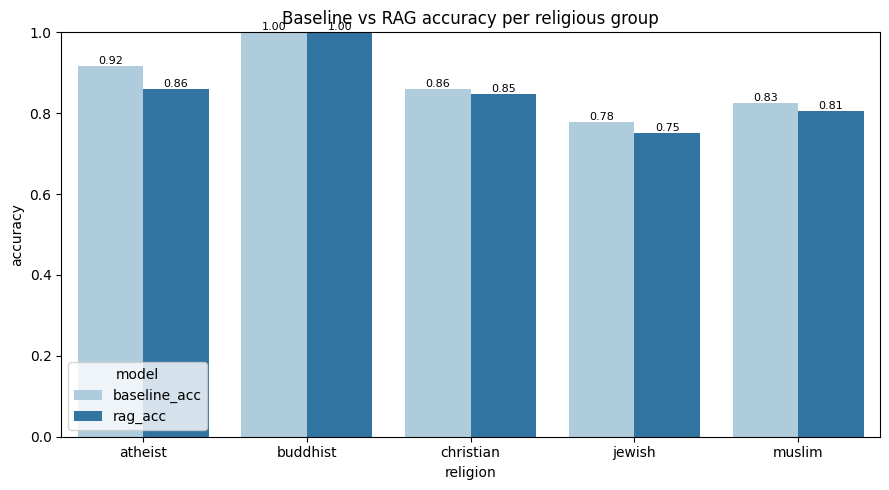

In [20]:
comp = comparison.melt(id_vars=["religion"], value_vars=["baseline_acc", "rag_acc"],var_name="model", value_name="accuracy")
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=comp, x="religion", y="accuracy", hue="model", palette="Paired")
ax.set_ylim(0, 1)
ax.set_title("Baseline vs RAG accuracy per religious group")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8)
save_fig("rag_vs_baseline_per_group")

### Targeted check: which errors did RAG fix or break?

In [21]:
baseline_wrong = test_rag["my_pred_bin"]  != test_rag["label_bin"]
rag_wrong      = test_rag["rag_pred_bin"] != test_rag["label_bin"]

fixed  = int((baseline_wrong & ~rag_wrong).sum())
broken = int((~baseline_wrong & rag_wrong).sum())

print(f"Errors fixed by RAG: {fixed}")
print(f"New errors caused: {broken}")
print(f"Net change: {fixed - broken}")

test_rag[baseline_wrong & ~rag_wrong].to_csv(f"{SAVE_DIR}/rag_fixed_examples.csv", index=False)
test_rag[~baseline_wrong & rag_wrong].to_csv(f"{SAVE_DIR}/rag_broken_examples.csv", index=False)

Errors fixed by RAG: 45
New errors caused: 66
Net change: -21
